In [114]:
#Análise de top 100 músicas do Spotify da história do app até a disponibilização do dataset
#no site kaggle.com, onde também há 2 arquivos .csv do chamado Spotify Wrapped 2025
#source: https://www.kaggle.com/datasets/alitaqishah/spotify-wrapped-2025-top-songs-and-artists

In [115]:
#import das bibliotecas necessárias
import random
import pandas as pd
import numpy as np

In [116]:
#leitura do arquivo .csv onde estão os dados
df_spotifySongs = pd.read_csv('spotify_alltime_top100_songs.csv')

In [117]:
#lista de colunas e as 10 primeiras linhas do dataset pra melhor compreensão dos dados
df_spotifySongs.head(10)

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100
5,6,Stay,The Kid LAROI & Justin Bieber,3.87,Pop,170,2021,Australia,True,0.59,0.80,0.60,0.00,Spotify All-Time Most Streamed Top 100
6,7,Believer,Imagine Dragons,3.76,Alt Rock,125,2017,USA,False,0.33,0.86,0.45,0.07,Spotify All-Time Most Streamed Top 100
7,8,Rockstar,Post Malone ft. 21 Savage,3.72,Hip-Hop,159,2017,USA,True,0.55,0.52,0.13,0.08,Spotify All-Time Most Streamed Top 100
8,9,Dance Monkey,Tones and I,3.69,Pop,98,2019,Australia,False,0.83,0.63,0.73,0.14,Spotify All-Time Most Streamed Top 100
9,10,Happier,Marshmello & Bastille,3.65,EDM/Pop,100,2018,USA/UK,False,0.62,0.82,0.96,0.02,Spotify All-Time Most Streamed Top 100


In [118]:
#1 - Classificando as músicas do artista The Weeknd pelo total de streams
filterTheWeeknd = df_spotifySongs['artist'] == 'The Weeknd'
resultado = df_spotifySongs[filterTheWeeknd].sort_values(by='total_streams_billions', ascending=False)

print(resultado)

    alltime_rank       song_title      artist  total_streams_billions  \
0              1  Blinding Lights  The Weeknd                    5.26   
28            29  Save Your Tears  The Weeknd                    2.88   
29            30      Die For You  The Weeknd                    2.86   

   primary_genre  bpm  release_year artist_country  explicit  danceability  \
0      Synth-Pop  171          2019         Canada     False          0.51   
28     Synth-Pop  118          2020         Canada     False          0.68   
29           R&B   95          2016         Canada     False          0.40   

    energy  valence  acousticness                            dataset_part  
0     0.80     0.33          0.00  Spotify All-Time Most Streamed Top 100  
28    0.82     0.78          0.01  Spotify All-Time Most Streamed Top 100  
29    0.55     0.32          0.04  Spotify All-Time Most Streamed Top 100  


In [119]:
#2 - mostrando as músicas de rock do top 100, organizado por posição histórica
filterRock = df_spotifySongs['primary_genre'].str.contains('Rock')
resultadoRock = df_spotifySongs[filterRock].sort_values(by='alltime_rank', ascending=True)
print(resultadoRock)

    alltime_rank                   song_title               artist  \
6              7                     Believer      Imagine Dragons   
23            24               Counting Stars          OneRepublic   
32            33              Sweater Weather    The Neighbourhood   
38            39                         Numb          Linkin Park   
41            42                  Radioactive      Imagine Dragons   
51            52                      Falling         Harry Styles   
52            53                      Thunder      Imagine Dragons   
56            57                   High Hopes  Panic! At The Disco   
58            59               Way Down We Go                KALEO   
68            69                Wrecking Ball          Miley Cyrus   
73            74             Beautiful Things         Benson Boone   
77            78  Welcome To The Black Parade  My Chemical Romance   
78            79                         Iris        Goo Goo Dolls   
83            84    

In [120]:
#3 - média de bilhões de streams por artista
df_spotifySongs.groupby('artist')['total_streams_billions'] \
    .mean().sort_values(ascending=False).head(10)

artist
Lewis Capaldi                    4.050000
Post Malone & Swae Lee           3.980000
Drake                            3.920000
The Kid LAROI & Justin Bieber    3.870000
Post Malone ft. 21 Savage        3.720000
Tones and I                      3.690000
The Weeknd                       3.666667
Marshmello & Bastille            3.650000
Shawn Mendes & Camila Cabello    3.620000
Dua Lipa                         3.520000
Name: total_streams_billions, dtype: float64

In [121]:
#4 - contagem de gêneros que mais se repetem no top 100
df_spotifySongs['primary_genre'].value_counts()

primary_genre
Pop              17
Indie Pop        12
Alt Rock          7
Hip-Hop           7
Synth-Pop         6
Pop Rock          6
EDM/Pop           4
Pop Punk          3
Hip-Hop/Pop       2
Afrobeats/Pop     2
Latin Pop         2
Funk/Pop          2
Indie Rock        2
R&B/Pop           2
Indie Folk        2
Pop/Dancehall     1
Pop/Folk          1
Nu-Disco          1
Electropop        1
Pop Rap           1
Pop/Country       1
Pop/Funk          1
Emo Rap           1
R&B               1
Reggaeton         1
Pop/Soul          1
Grunge            1
Art Pop           1
Holiday Pop       1
Trap Pop          1
Blues Rock        1
Folk Pop          1
Acoustic Pop      1
Soul/R&B          1
K-Pop/Pop         1
Country/Pop       1
R&B/Soul          1
Art Rock          1
Pop/R&B           1
Name: count, dtype: int64

In [122]:
#5 - gerando linha randômica do dataframe
import random as rd
rd1 = rd.randint(0, 100)
RdiLoc = df_spotifySongs.iloc[[rd1]]
print(RdiLoc)

   alltime_rank song_title                         artist  \
5             6       Stay  The Kid LAROI & Justin Bieber   

   total_streams_billions primary_genre  bpm  release_year artist_country  \
5                    3.87           Pop  170          2021      Australia   

   explicit  danceability  energy  valence  acousticness  \
5      True          0.59     0.8      0.6           0.0   

                             dataset_part  
5  Spotify All-Time Most Streamed Top 100  


In [123]:
#6 exibindo os países com maior média de streams
df_spotifySongs.groupby('artist_country')['total_streams_billions'] \
 .mean().sort_values(ascending=False).head(10)

artist_country
Canada/Cuba    3.620000
USA/UK         3.275000
Canada         3.140000
Nigeria/USA    3.020000
Australia      2.944000
UK             2.731111
USA            2.420385
Iceland        2.290000
Puerto Rico    2.150000
South Korea    2.150000
Name: total_streams_billions, dtype: float64

In [124]:
#7 - as músicas mais dançantes e seus respectivos artistas, posições e streams
df_spotifySongs[['artist', 'alltime_rank', 'total_streams_billions', 'danceability']].sort_values(by='danceability', ascending=False).head(10)

,artist,alltime_rank,total_streams_billions,danceability
31,Mark Ronson ft. Bruno Mars,32,2.53,0.90
76,ROSE & Bruno Mars,77,1.66,0.86
8,Tones and I,9,3.69,0.83
1,Ed Sheeran,2,4.90,0.83
43,Kendrick Lamar,44,1.50,0.82
98,Drake ft. Lil Durk,99,3.05,0.82
40,Sabrina Carpenter,41,1.76,0.80
26,Rema & Selena Gomez,27,3.02,0.80
4,Drake,5,3.92,0.79
54,BTS,55,1.60,0.79


In [125]:
#8 contagem de músicas explícitas usando estrutura de repetição
explicitT = 0
explicitF = 0
for index, row in df_spotifySongs.iterrows() :
    if (row['explicit']) :
        explicitT +=1
    else:
        explicitF +=1

print("Explícitas: ", explicitT)
print("Não explícitas: ", explicitF)

Explícitas:  13
Não explícitas:  87


In [126]:
#9 contagem de músicas explícitas usando counts (bem mais fácil)
df_spotifySongs['explicit'].value_counts()

explicit
False    87
True     13
Name: count, dtype: int64

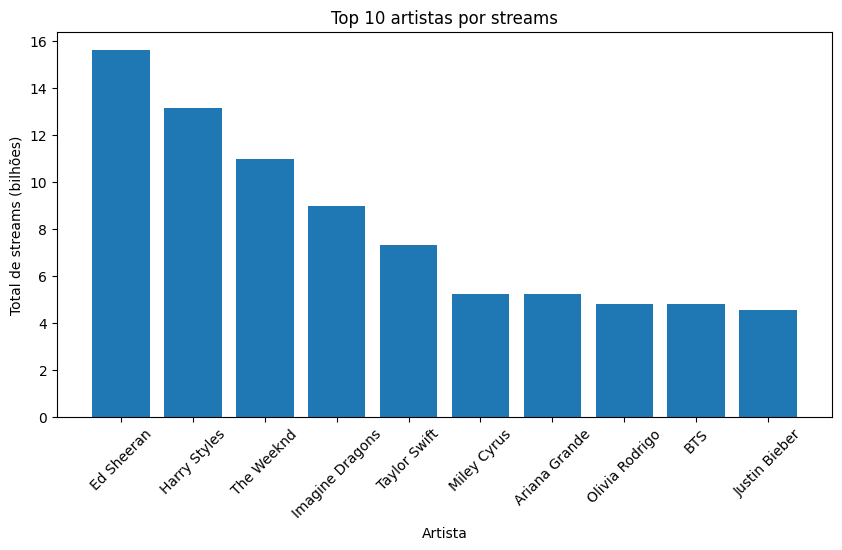

In [127]:
#10 - gráfico de barra com os artisas qie mais se repetem e seus streams
import matplotlib.pyplot as plt

top_artists = (
    df_spotifySongs.groupby('artist')['total_streams_billions'].sum()
    .sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_artists.index, top_artists.values)

plt.title("Top 10 artistas por streams")
plt.xlabel("Artista")
plt.ylabel("Total de streams (bilhões)")

plt.xticks(rotation=45)
plt.show()

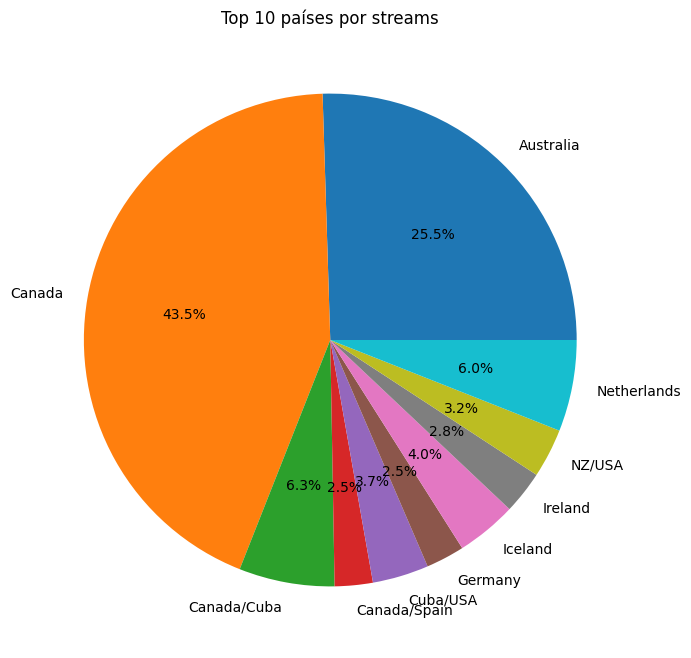

In [128]:
#gráfico de pizza com países com maior quantidade de streams
top_countries = (df_spotifySongs.groupby(['artist_country'])['total_streams_billions']
.sum().head(10))

plt.figure(figsize=(8,8))
plt.title("Top 10 países por streams")
plt.pie(top_countries.values, labels=top_countries.index,autopct='%1.1f%%')
plt.show()
